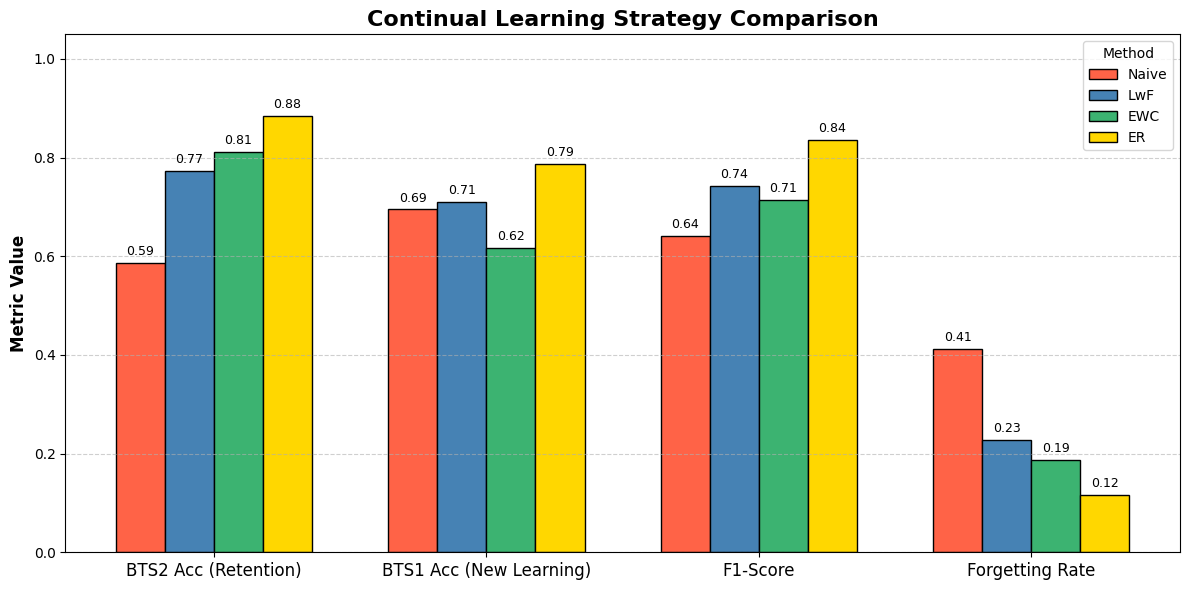

Saved bar chart to: ../outputs/Continual_Learning_Bar_Comparison.png

Summary Metrics Table:
       BTS2 Acc (Retention)  BTS1 Acc (New Learning)  F1-Score  \
Naive                 0.587                    0.695     0.641   
LwF                   0.773                    0.710     0.742   
EWC                   0.812                    0.616     0.714   
ER                    0.884                    0.787     0.836   

       Forgetting Rate  
Naive            0.413  
LwF              0.227  
EWC              0.188  
ER               0.116  


In [9]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths ---
DATA_DIR = "../data"
METRICS_FILE = os.path.join(DATA_DIR, "comparison_metrics.json")
OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Load JSON metrics ---
with open(METRICS_FILE, 'r') as f:
    all_model_data = json.load(f)

# --- Consolidate metrics ---
model_names_map = {
    'Naive': 'Naive',
    'LwF': 'LwF',
    'EWC': 'EWC',
    'ER': 'ER'
}

consolidated_data = {}
for key, name in model_names_map.items():
    data = all_model_data.get(key, {})
    consolidated_data[name] = {
        'BTS2 Acc (Retention)': data.get("accuracy_data", {}).get("BTS2 (Old)", np.nan),
        'BTS1 Acc (New Learning)': data.get("accuracy_data", {}).get("BTS1 (New)", np.nan),
        'F1-Score': data.get("metrics_data", {}).get("F1-Score", np.nan),
        'Forgetting Rate': data.get("metrics_data", {}).get("Forgetting Rate", np.nan)
    }

df_all = pd.DataFrame.from_dict(consolidated_data, orient='index')

# --- Plot bar chart ---
df_plot_T = df_all.T  # transpose to have metrics on x-axis

model_colors = {
    'Naive': '#FF6347',  # Tomato Red
    'LwF': '#4682B4',    # Steel Blue
    'EWC': '#3CB371',    # Medium Sea Green
    'ER': '#FFD700',     # Gold
}

fig, ax = plt.subplots(figsize=(12,6))

n_metrics = len(df_plot_T.index)
n_models = len(df_plot_T.columns)
bar_width = 0.18
x = np.arange(n_metrics)

# Plot bars
for i, model_name in enumerate(df_plot_T.columns):
    offset = (i - (n_models-1)/2) * bar_width
    color = model_colors.get(model_name, 'gray')
    bars = ax.bar(x + offset, df_plot_T[model_name].values, bar_width, label=model_name, color=color, edgecolor='black')
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

# Configure axes
ax.set_xticks(x)
ax.set_xticklabels(df_plot_T.index, fontsize=12)
ax.set_ylabel("Metric Value", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title("Continual Learning Strategy Comparison", fontsize=16, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(title="Method")

# Save figure
bar_path = os.path.join(OUT_DIR, "Continual_Learning_Bar_Comparison.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=200)
plt.show()

print(f"Saved bar chart to: {bar_path}")
print("\nSummary Metrics Table:")
print(df_all.round(3))
